# EuroSat classification
This project uses pretrained model and transfer learning to classify Eurosat images

In [1]:
import torch
from utils import load_device

In [2]:
device=load_device()

PyTorch Version: 2.8.0+cu126
Using GPU: NVIDIA GeForce GTX 1660 Ti


In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
weights=EfficientNet_V2_S_Weights.DEFAULT
auto_transform=weights.transforms()
dataset = datasets.EuroSAT(root='./datasets', download=True)

In [4]:
n_classes=len(dataset.classes)

In [5]:
from torchvision import transforms as T 
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import copy
generator = torch.Generator().manual_seed(42)
train_trans=T.Compose([
  T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2,contrast=0.2),
    auto_transform
])
train_set,val_set,_=random_split(dataset,lengths=[0.1,0.2,0.7],generator=generator)
train_set.dataset = copy.copy(dataset)
val_set.dataset = copy.copy(dataset)
train_set.dataset.transform = train_trans
val_set.dataset.transform = auto_transform
train_loader = DataLoader(
    train_set, 
    batch_size=64, 
    shuffle=True, 
    num_workers=4,     
    pin_memory=True     
)

val_loader = DataLoader(
    val_set, 
    batch_size=64, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

In [6]:
len(val_loader)

85

In [7]:
model=efficientnet_v2_s(weights=weights)
for param in model.parameters():
    param.requires_grad=False

In [8]:
import torch.nn as nn
num_features = model.classifier[1].in_features
model.classifier[1]=nn.Linear(num_features,n_classes)
model=model.to(device)

In [9]:
def he_init(module):
    if isinstance(module,nn.Linear):
        nn.init.kaiming_uniform_(module.weight,generator=torch.Generator(device=device).manual_seed(42))
        nn.init.zeros_(module.bias)

In [10]:
_=model.classifier[1].apply(he_init)

In [11]:
n_epochs=20
optimizer=torch.optim.AdamW(model.classifier.parameters(),lr=1e-3,weight_decay=0.01)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=n_epochs, eta_min=1e-6)

In [12]:
import torchmetrics
metric=torchmetrics.Accuracy(task='multiclass',num_classes=n_classes).to(device)
xentropy=nn.CrossEntropyLoss()

In [13]:
from utils import train

In [14]:
history=train(model,optimizer,xentropy,metric,train_loader,n_epochs,device,track_valid=False,scheduler=scheduler)

Epoch 1/20, train loss: 1.7807, train metric: 0.4419,  in 37.0s
Epoch 2/20, train loss: 1.1948, train metric: 0.6919,  in 36.0s
Epoch 3/20, train loss: 0.9812, train metric: 0.7241,  in 35.5s
Epoch 4/20, train loss: 0.8602, train metric: 0.7607,  in 35.9s
Epoch 5/20, train loss: 0.8036, train metric: 0.7693,  in 35.8s
Epoch 6/20, train loss: 0.7687, train metric: 0.7644,  in 36.0s
Epoch 7/20, train loss: 0.7164, train metric: 0.7767,  in 35.5s
Epoch 8/20, train loss: 0.6890, train metric: 0.7937,  in 35.5s
Epoch 9/20, train loss: 0.6560, train metric: 0.7933,  in 35.5s
Epoch 10/20, train loss: 0.6468, train metric: 0.7985,  in 35.8s
Epoch 11/20, train loss: 0.6408, train metric: 0.8026,  in 35.8s
Epoch 12/20, train loss: 0.6097, train metric: 0.8144,  in 35.8s
Epoch 13/20, train loss: 0.5929, train metric: 0.8219,  in 36.0s
Epoch 14/20, train loss: 0.6165, train metric: 0.8048,  in 35.9s
Epoch 15/20, train loss: 0.5986, train metric: 0.8133,  in 37.7s
Epoch 16/20, train loss: 0.6047, t

In [16]:
torch.save(model.state_dict(), "Transfer_Model.pt")

In [92]:
def evaluate_with_errors(model,data_loader,metric,device):
    model.eval()
    metric.reset()
    errors={'input':[],'true_label':[],'predicted_label':[]}
    with torch.no_grad():
        for X_batch,y_batch in data_loader:
            X_batch,y_batch=X_batch.to(device),y_batch.to(device)
            y_pred_logits=model(X_batch)
            y_pred_labels=torch.argmax(y_pred_logits,dim=1)
            error_mask=(y_pred_labels!=y_batch)
            if error_mask.any(): 
                X_wrong=X_batch[error_mask].cpu()               
                y_true=y_batch[error_mask].cpu()
                y_predicted=y_pred_labels[error_mask].cpu()
                for i in range(len(X_wrong)):                    
                    errors['input'].append(torch.squeeze(X_wrong[i],dim=0).permute(1, 2, 0))
                    errors['true_label'].append(y_true[i].item())
                    errors['predicted_label'].append(y_predicted[i].item())
            metric.update(y_pred_logits,y_batch)
    return metric.compute(),errors

In [93]:
score,errors=evaluate_with_errors(model,val_loader,metric,device)

In [94]:
score.item()

0.8446296453475952

In [152]:
import numpy as np
def plot_imgs(images,labels,n_cols):
    n_rows=int(np.ceil(len(labels) / n_cols))
    fig,axs=plt.subplots(n_rows,n_cols,figsize=(2*n_cols,2*n_rows))
    axs=axs.flatten()
    fig.suptitle("Example of each class")
    for i in range(n_rows*n_cols):
        if i <len(labels):
            axs[i].imshow(images[i])
            axs[i].set_title(classes[i],fontsize=12, pad=8)
        axs[i].set_axis_off()
    plt.tight_layout(h_pad=2.0)
    plt.show()

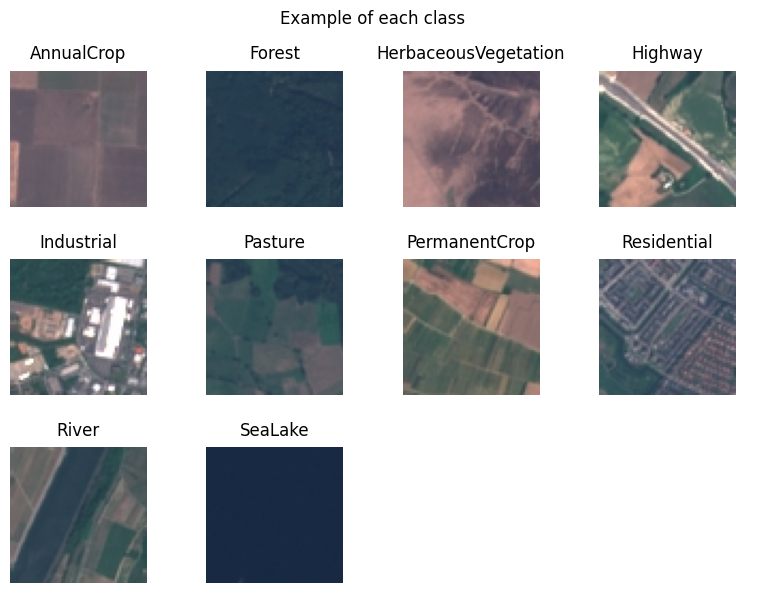

In [153]:
labels,indices=np.unique(dataset.targets,return_index=True)
classes=[dataset.classes[l] for l in labels]
images=[dataset[i][0]for i in indices]
plot_imgs(images,classes,4)

In [149]:
titles=[f" {dataset.classes[true]} | {dataset.classes[predicted]} " for true,predicted in zip(errors['true_label'],errors['predicted_label'])]

In [150]:
def plot_errors(images,labels,n_cols,std,mean):
    n_rows=int(np.ceil(len(labels) / n_cols))
    fig,axs=plt.subplots(n_rows,n_cols,figsize=(2*n_rows,2*n_cols))
    axs=axs.flatten()
    fig.suptitle("True | Predicted")
    for i in range(n_rows*n_cols):
        if i <len(labels):
            image=images[i]
            image=image*std+mean
            image = np.clip(image, 0, 1)
            axs[i].imshow(image)
            axs[i].set_title(labels[i],fontsize=9, pad=6)
        axs[i].set_axis_off()
    plt.tight_layout(h_pad=1.5)
    plt.show()

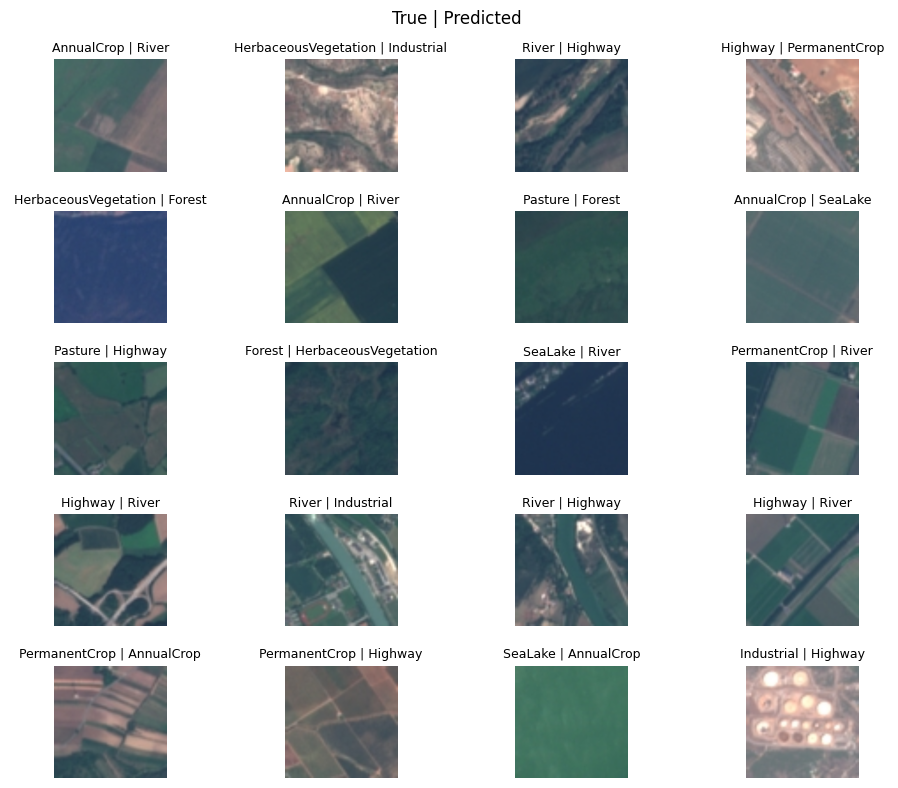

In [151]:
n_images=20
std=torch.tensor(auto_transform.std)
mean=torch.tensor(auto_transform.mean)
start_idx=np.random.randint(n_images,len(errors['input'])-n_images,size=(),dtype=int)
end_idx=start_idx+n_images
plot_errors(errors['input'][start_idx:end_idx],titles[start_idx:end_idx],4,std,mean)